In [1]:
%pip install shap --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import joblib
import shap
import pandas as pd
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path().resolve()

while not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.append(str(ROOT))

C:\Users\karen\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
X_test = pd.read_csv(r"../data/clean/X_test.csv")

In [4]:
model_path = Path("../artifacts/final_model.pkl")
model = joblib.load(model_path)

In [5]:
preprocessor = model.named_steps["features"]
estimator = model.named_steps["model"]

In [6]:
X_transformed = preprocessor.transform(X_test)

C:\Users\karen\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [7]:
ct = model.named_steps["features"].named_steps["preprocessing"]

feature_names = ct.get_feature_names_out()

In [8]:
explainer = shap.Explainer(estimator, X_transformed)
shap_values = explainer(X_transformed)

In [9]:
importance = np.abs(shap_values.values).mean(axis=0)

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

print(df_importance.head(20))

                   feature  importance
4         num__OverallQual    0.051816
6           num__YearBuilt    0.047963
16          num__GrLivArea    0.038195
5         num__OverallCond    0.031769
38            num__TotalSF    0.031183
14           num__2ndFlrSF    0.026102
42        nom__MSZoning_RL    0.025159
27         num__GarageArea    0.024666
13           num__1stFlrSF    0.024496
122  nom__RoofMatl_CompShg    0.023317
116   nom__RoofStyle_Gable    0.021276
1          num__MSSubClass    0.020229
165  nom__Foundation_PConc    0.019047
118     nom__RoofStyle_Hip    0.018751
39   nom__MSZoning_C (all)    0.018624
9          num__BsmtFinSF1    0.017466
225        ord__Functional    0.016961
218        ord__GarageQual    0.016749
17       num__BsmtFullBath    0.015039
7        num__YearRemodAdd    0.014813


Shap values genera la explicabilidad con las variables codificadas (con one hot en el caso de las categoricas), entonces para estas variables se agruparán (y luego se ponderan por cantidad) los shap values para obtener un valor global por cada variable original. 

In [10]:
# para guardar las más importantes y usarlas en la página de streamlit
import re

def get_original_feature(name):
    name = name.split("__")[-1]  # quitar prefijo (num__, nom__, etc.)
    
    # eliminar categoría en one-hot
    if "_" in name:
        return name.split("_")[0]
    
    return name

df_importance["original_feature"] = df_importance["feature"].apply(get_original_feature)

# agrupar
#grouped = df_importance.groupby("original_feature")["importance"] \
#    .sum() \
#    .sort_values(ascending=False)

# ranking ajustado por número de categorías
grouped = df_importance.groupby("original_feature").agg({
    "importance": ["sum", "count"]
})

grouped["adjusted"] = grouped[("importance", "sum")] / grouped[("importance", "count")]

grouped = grouped.sort_values(("adjusted"), ascending=False)

print(grouped.head(30))

top_30_features = grouped.head(30).index.tolist()

                 importance        adjusted
                        sum count          
original_feature                           
OverallQual        0.051816     1  0.051816
YearBuilt          0.047963     1  0.047963
GrLivArea          0.038195     1  0.038195
OverallCond        0.031769     1  0.031769
TotalSF            0.031183     1  0.031183
2ndFlrSF           0.026102     1  0.026102
GarageArea         0.024666     1  0.024666
1stFlrSF           0.024496     1  0.024496
MSSubClass         0.020229     1  0.020229
BsmtFinSF1         0.017466     1  0.017466
Functional         0.016961     1  0.016961
GarageQual         0.016749     1  0.016749
BsmtFullBath       0.015039     1  0.015039
YearRemodAdd       0.014813     1  0.014813
Fireplaces         0.014793     1  0.014793
HalfBath           0.014048     1  0.014048
MSZoning           0.062709     5  0.012542
TotalBsmtSF        0.012444     1  0.012444
TotRmsAbvGrd       0.012394     1  0.012394
BsmtExposure       0.011309     

In [11]:
df_grouped = grouped.reset_index()
df_grouped.columns = [
    "_".join(col).strip("_") for col in df_grouped.columns
]

In [12]:
df_grouped.columns

Index(['original_feature', 'importance_sum', 'importance_count', 'adjusted'], dtype='object')

In [13]:
import joblib

# top 30 (para inputs)
joblib.dump(top_30_features, "../artifacts/top_30_features.pkl")

# ranking completo (para visualización)
joblib.dump(df_grouped, "../artifacts/shap_global_importance.pkl")

['../artifacts/shap_global_importance.pkl']

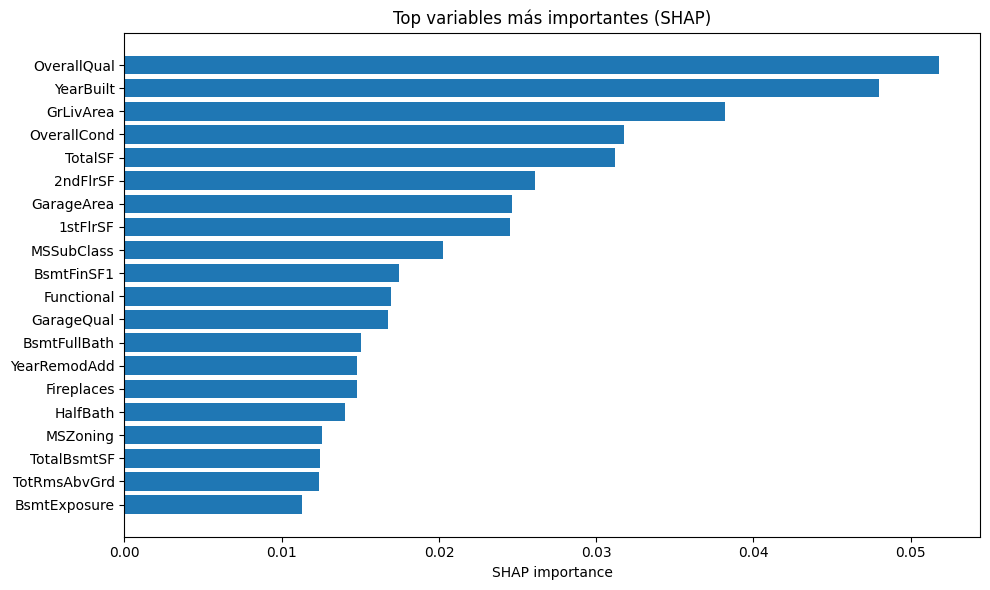

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_plot = df_grouped.head(20)[::-1]

plt.barh(top_plot["original_feature"], top_plot["adjusted"])
plt.xlabel("SHAP importance")
plt.title("Top variables más importantes (SHAP)")

plt.tight_layout()
plt.savefig("../artifacts/shap_importance.png")
plt.show()

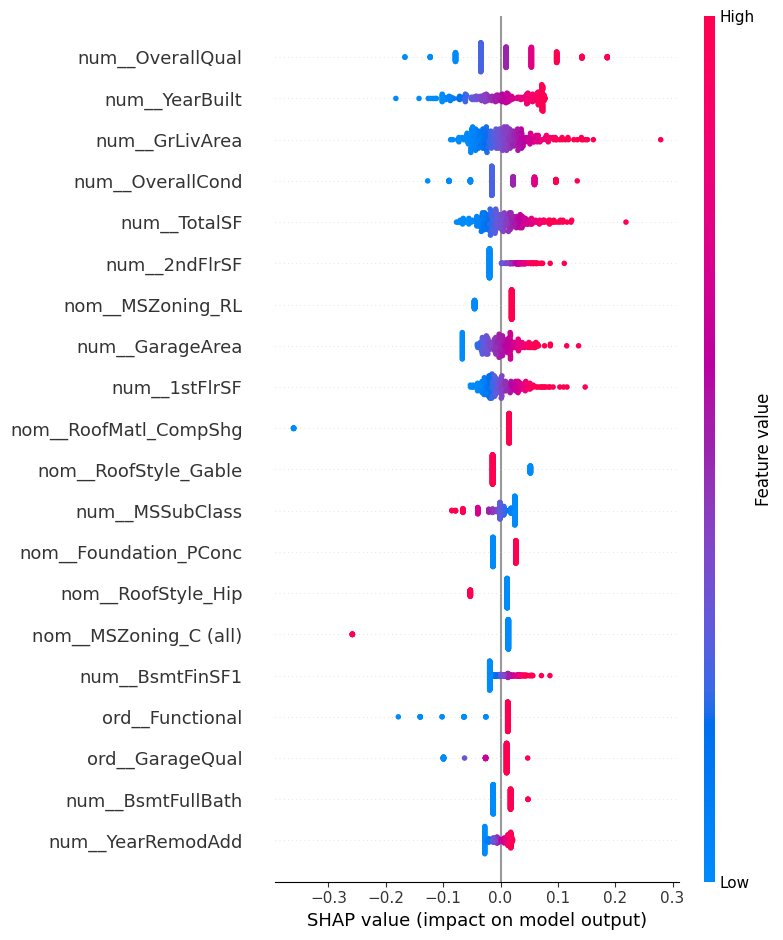

In [15]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names
)

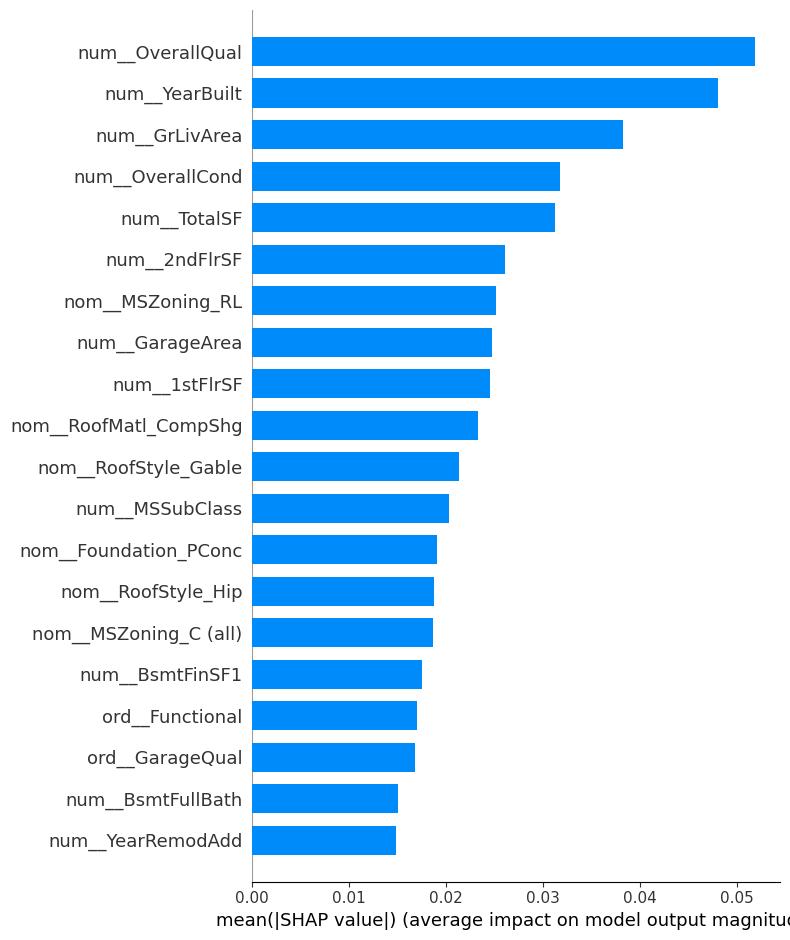

In [16]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

# Regresion lineal importancia

In [17]:
import pandas as pd
import numpy as np

def get_linear_importance(pipeline):
    """
    Extrae importancia de variables desde un pipeline:
    Pipeline([
        ("features", ...),
        ("model", LinearRegression)
    ])
    """

    # =========================
    # 1. Obtener partes
    # =========================
    model = pipeline.named_steps["model"]
    features_pipe = pipeline.named_steps["features"]

    # preprocessing (ColumnTransformer)
    preprocessor = features_pipe.named_steps["preprocessing"]

    # =========================
    # 2. Nombres de features transformadas
    # =========================
    feature_names = preprocessor.get_feature_names_out()

    # =========================
    # 3. Coeficientes
    # =========================
    coefs = model.coef_

    # =========================
    # 4. DataFrame
    # =========================
    df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)

    return df

In [18]:
def group_importance(df):
    
    def extract_original(feature_name):
        # Ejemplo: nom__Neighborhood_NridgHt → Neighborhood
        name = feature_name.split("__")[-1]
        return name.split("_")[0]

    df["original_feature"] = df["feature"].apply(extract_original)

    grouped = (
        df.groupby("original_feature")["abs_coef"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    return grouped

In [19]:
importance_df = get_linear_importance(model)

# Top features individuales
print(importance_df.head(20))

# Importancia por variable original
grouped_importance = group_importance(importance_df)
print(grouped_importance.head(15))

                       feature      coef  abs_coef
121      nom__RoofMatl_ClyTile -2.218166  2.218166
98        nom__Condition2_PosN -0.767952  0.767952
127      nom__RoofMatl_WdShngl  0.461043  0.461043
124         nom__RoofMatl_Roll  0.378539  0.378539
126      nom__RoofMatl_WdShake  0.376316  0.376316
122      nom__RoofMatl_CompShg  0.375753  0.375753
123        nom__RoofMatl_Metal  0.319865  0.319865
125      nom__RoofMatl_Tar&Grv  0.306650  0.306650
97        nom__Condition2_PosA  0.288194  0.288194
39       nom__MSZoning_C (all) -0.271912  0.271912
95       nom__Condition2_Feedr  0.255857  0.255857
195      nom__MiscFeature_TenC -0.239038  0.239038
130   nom__Exterior1st_BrkComm -0.220554  0.220554
70   nom__Neighborhood_MeadowV -0.170584  0.170584
99        nom__Condition2_RRAe -0.167870  0.167870
174          nom__Heating_Wall  0.166752  0.166752
138     nom__Exterior1st_Stone  0.160811  0.160811
203          nom__SaleType_Oth  0.138056  0.138056
82   nom__Neighborhood_StoneBr 

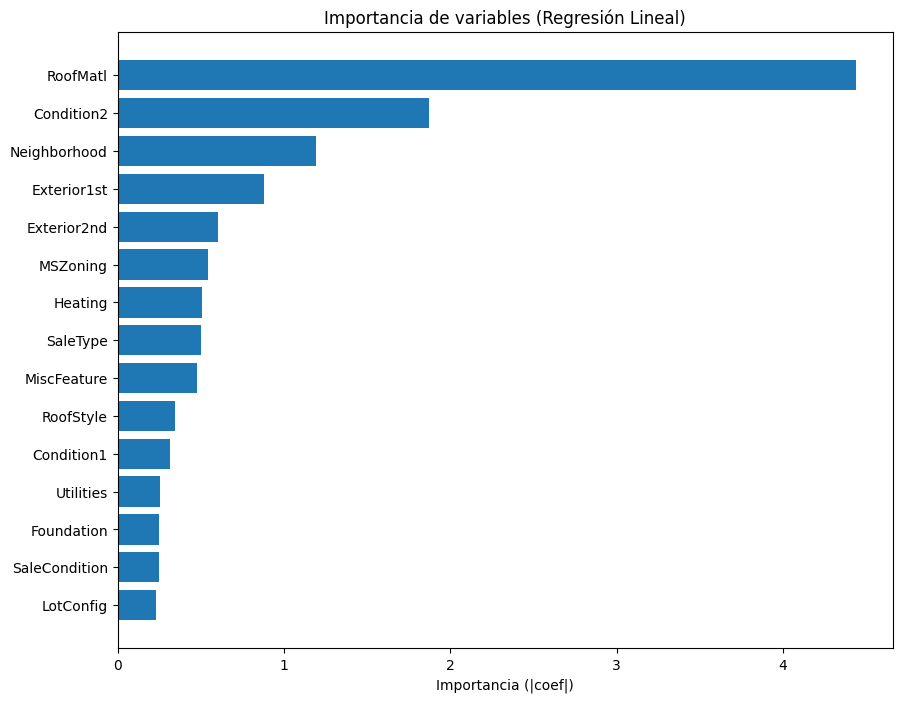

In [20]:
import matplotlib.pyplot as plt


top = grouped_importance.head(15)

plt.figure(figsize=(10, 8))
plt.barh(top["original_feature"], top["abs_coef"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables (Regresión Lineal)")
plt.xlabel("Importancia (|coef|)")
plt.show()